# 04a -- ECG Forecasting: WaveNetForecaster v7 (fixed)

### Root causes of the flat-line / mean-collapse / early-stop-at-9-epochs failure in v6

1. **No real forecasting head.** `output_head` was a 1x1 Conv applied to the causal stack, so the output length equals the *input* time axis, not `HORIZON`. The shape assert (`out.shape == (B,HORIZON,N_LEADS)`) only passed because `INPUT_LEN == HORIZON` in this dataset (both 490) -- so the model was never actually forced to forecast, it just passed features through. Fixed with a dedicated head: global pooled MLP forecast blended with a causal head.
2. **Spike-weighted loss from epoch 1.** `SpikeWeightedMSE(weight=4.0)` punished the model 4x on the hardest samples before it had learned the basic waveform shape. At random init this pushes gradients to noise and the optimizer settles on predicting the mean (flat line) because that minimizes the *average* weighted loss. Fixed with a curriculum: plain MSE for the first 10 epochs, then switch to spike-weighted MSE.
3. **Capacity too low / LR too aggressive together.** 48 channels + `max_lr=5e-4` with only 10% warmup destabilized early training, causing the early plateau and stop at ~9 epochs. Fixed with 96 channels, `max_lr=2e-4`, 20% warmup, and patience raised to 20 with 80 epoch budget.
4. **No input normalisation.** Raw lead amplitudes could vary in scale, encouraging the model to learn a safe near-zero output. Fixed with `InstanceNorm1d` on the input.

**Nothing about the data pipeline changed** -- cells 0-5 (load data, dataset, augmentation) are untouched and were already correct.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# CELL 1 -- IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print("OK Imports ready")


PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
OK Imports ready


In [6]:
import os
import numpy as np

# Set project root
PROJECT_ROOT = '/content/drive/MyDrive/his/HIS Project'
os.chdir(PROJECT_ROOT)

# Redefine SAVE_DIR correctly
SAVE_DIR = 'data/processed'  # No ../

# Verify the path exists
if os.path.exists(SAVE_DIR):
    print(f"✅ Data directory found: {SAVE_DIR}")
    print(f"📄 Files available: {os.listdir(SAVE_DIR)[:10]}")
else:
    print(f"❌ Data directory not found: {SAVE_DIR}")
    # Try alternative locations
    alt_paths = [
        'data/processed',
        '../data/processed',
        '../../data/processed',
        '/content/drive/MyDrive/his/HIS Project/data/processed',
    ]
    for alt in alt_paths:
        if os.path.exists(alt):
            print(f"✅ Found data at: {alt}")
            SAVE_DIR = alt
            break

✅ Data directory found: data/processed
📄 Files available: ['metadata.pkl', 'X_raw.npy', 'classes.pkl', 'y.npy', 'load_config.pkl', 'pca_train.pkl', 'norm_params.pkl', 'X_train_reduced.npy', 'y_train_reduced.npy', 'y_val_reduced.npy']


In [8]:
# CELL 2 -- LOAD DATA (FIXED FOR COLAB)
import os
import numpy as np
import pickle

# Set project root
PROJECT_ROOT = '/content/drive/MyDrive/his/HIS Project'
os.chdir(PROJECT_ROOT)

# ✅ CORRECT PATHS (no ../)
SAVE_DIR = 'data/processed'
FIG_DIR  = 'reports/figures/cnn_lstm_v6'
CKPT_DIR = 'checkpoints'

# Create directories
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"📍 Working directory: {os.getcwd()}")
print(f"📁 Data directory: {SAVE_DIR}")

# Check if data files exist before loading
required_files = [
    'X_train.npy', 'y_train.npy',
    'X_val.npy', 'y_val.npy',
    'X_test.npy', 'y_test.npy',
    'config.pkl'
]

print("\n🔍 Checking required files:")
all_exist = True
for f in required_files:
    file_path = os.path.join(SAVE_DIR, f)
    if os.path.exists(file_path):
        print(f"  ✅ {f}")
    else:
        print(f"  ❌ {f} NOT FOUND")
        all_exist = False

if not all_exist:
    print("\n❌ Some files are missing. Available files:")
    if os.path.exists(SAVE_DIR):
        print(os.listdir(SAVE_DIR))
    raise FileNotFoundError("Data files not found. Please check your data directory.")

# Load data
print("\n📊 Loading data...")
X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

LEAD_NAMES = cfg['lead_names']
FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']

print("\n✅ Data loaded successfully!")
print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"Input   : {INPUT_LEN} samples = {INPUT_LEN/FS:.2f}s")
print(f"Horizon : {HORIZON}  samples = {HORIZON/FS:.2f}s")
assert y_train.ndim == 3 and y_train.shape[1] == HORIZON and y_train.shape[2] == N_LEADS
print("\n✅ All checks passed!")

📍 Working directory: /content/drive/MyDrive/his/HIS Project
📁 Data directory: data/processed

🔍 Checking required files:
  ✅ X_train.npy
  ✅ y_train.npy
  ✅ X_val.npy
  ✅ y_val.npy
  ✅ X_test.npy
  ✅ y_test.npy
  ✅ config.pkl

📊 Loading data...

✅ Data loaded successfully!
X_train : (31362, 490, 12)   y_train : (31362, 490, 12)
X_val   : (3920, 490, 12)     y_val   : (3920, 490, 12)
X_test  : (2198, 490, 12)    y_test  : (2198, 490, 12)
Input   : 490 samples = 4.90s
Horizon : 490  samples = 4.90s

✅ All checks passed!


In [9]:
# CELL 3 -- DATASET WITH AUGMENTATION (unchanged from v5 -- working well)
class ECGForecastDataset(Dataset):
    def __init__(self, X, y, channel_first=False, augment=False):
        self.X       = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y       = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.channel_first = channel_first
        self.augment = augment

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x, y = self.X[idx].clone(), self.y[idx].clone()
        if self.augment:
            scale = torch.empty(1).uniform_(0.85, 1.15)
            x = x * scale
            y = y * scale
            x = x + torch.randn_like(x) * 0.01
        if self.channel_first:
            x = x.permute(1, 0)
        return x, y

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 channel_first=False, batch_train=128, batch_eval=256):
    kw = dict(num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
    tr = DataLoader(ECGForecastDataset(X_tr, y_tr, channel_first, augment=True),
                    batch_size=batch_train, shuffle=True, drop_last=True, **kw)
    vl = DataLoader(ECGForecastDataset(X_v,  y_v,  channel_first, augment=False),
                    batch_size=batch_eval, shuffle=False, **kw)
    te = DataLoader(ECGForecastDataset(X_te, y_te, channel_first, augment=False),
                    batch_size=batch_eval, shuffle=False, **kw)
    return tr, vl, te

cnn_tr, cnn_vl, cnn_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    channel_first=True, batch_train=128, batch_eval=256)

xb, yb = next(iter(cnn_tr))
print(f"Train batch : x={xb.shape}  y={yb.shape}")
print(f"Batches     : train={len(cnn_tr)} | val={len(cnn_vl)} | test={len(cnn_te)}")
print("OK DataLoaders ready -- augmentation ON")


Train batch : x=torch.Size([128, 12, 490])  y=torch.Size([128, 490, 12])
Batches     : train=245 | val=16 | test=9
OK DataLoaders ready -- augmentation ON


In [ ]:
# CELL 4 -- FIXED MODEL: WaveNetForecaster v7
class CausalDilatedBlock(nn.Module):
    def __init__(self, channels, dilation, kernel_size=7, dropout=0.10):
        super().__init__()
        self.causal_pad = (kernel_size - 1) * dilation
        self.conv_tanh = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=0, bias=False)
        self.conv_gate = nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=0, bias=False)
        self.bn_t = nn.BatchNorm1d(channels)
        self.bn_g = nn.BatchNorm1d(channels)
        self.skip_proj = nn.Conv1d(channels, channels, 1, bias=False)
        self.res_proj = nn.Conv1d(channels, channels, 1, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        xp = F.pad(x, (self.causal_pad, 0))
        gated = self.drop(torch.tanh(self.bn_t(self.conv_tanh(xp))) * torch.sigmoid(self.bn_g(self.conv_gate(xp))))
        return x + self.res_proj(gated), self.skip_proj(gated)


class WaveNetForecaster(nn.Module):
    DILATIONS = [1, 2, 4, 8, 16, 32, 64, 128]
    CHANNELS = 96
    KERNEL_SIZE = 7

    def __init__(self, n_leads=12, input_len=490, horizon=490, dropout=0.10):
        super().__init__()
        C = self.CHANNELS
        self.horizon = horizon
        self.n_leads = n_leads
        self.input_norm = nn.InstanceNorm1d(n_leads, affine=True)
        self.input_proj = nn.Sequential(nn.Conv1d(n_leads, C, 1, bias=False), nn.BatchNorm1d(C), nn.GELU())
        self.blocks = nn.ModuleList([CausalDilatedBlock(C, d, self.KERNEL_SIZE, dropout) for d in self.DILATIONS])

        mlp_hidden = C * 4
        self.forecast_head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(C, mlp_hidden), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(mlp_hidden, mlp_hidden), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(mlp_hidden, horizon * n_leads),
        )

        self.causal_head = nn.Sequential(
            nn.GELU(), nn.Conv1d(C, C // 2, 1, bias=False), nn.BatchNorm1d(C // 2), nn.GELU(),
            nn.Conv1d(C // 2, n_leads, 1))

        self.blend = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        x = self.input_norm(x)
        out = self.input_proj(x)
        skip_sum = torch.zeros_like(out)
        for blk in self.blocks:
            out, skip = blk(out)
            skip_sum = skip_sum + skip

        mlp_out = self.forecast_head(skip_sum).view(-1, self.horizon, self.n_leads)

        caus_out = self.causal_head(skip_sum)[:, :, -self.horizon:]
        caus_out = caus_out.permute(0, 2, 1)

        alpha = torch.sigmoid(self.blend)
        return alpha * mlp_out + (1 - alpha) * caus_out

    def enable_mc_dropout(self):
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()


K = WaveNetForecaster.KERNEL_SIZE
D = WaveNetForecaster.DILATIONS
rf = (K - 1) * sum(D) + 1
print(f"Receptive field : {rf} steps = {rf/100:.2f}s")
print("OK WaveNetForecaster v7 defined")


In [ ]:
# CELL 5 -- INSTANTIATE & SHAPE CHECK
model = WaveNetForecaster(n_leads=N_LEADS, input_len=INPUT_LEN, horizon=HORIZON, dropout=0.10).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    dummy = torch.randn(4, N_LEADS, INPUT_LEN).to(DEVICE)
    out = model(dummy)
    assert out.shape == (4, HORIZON, N_LEADS), f"Shape error: {out.shape}"
    print(f"Forward pass : {tuple(dummy.shape)} -> {tuple(out.shape)}")
    print(f"Output std   : {out.std().item():.4f}  (should be > 0.1 before training)")

print(f"Parameters   : {n_params:,}")
print(f"Device       : {DEVICE}")
print("OK Model ready")


In [ ]:
# CELL 6 -- CURRICULUM LOSS
SPIKE_W = 3.0
SPIKE_SIGMA = 2.0
CURRICULUM_EPOCHS = 10

class SpikeWeightedMSE(nn.Module):
    def __init__(self, spike_weight=SPIKE_W, spike_sigma=SPIKE_SIGMA):
        super().__init__()
        self.spike_weight = spike_weight
        self.spike_sigma = spike_sigma

    def forward(self, pred, target):
        std = target.std(dim=1, keepdim=True).clamp(min=1e-6)
        mask = (target.abs() > self.spike_sigma * std).float()
        w = 1.0 + (self.spike_weight - 1.0) * mask
        return (w * (pred - target) ** 2).mean()

mse_loss = nn.MSELoss()
spike_loss = SpikeWeightedMSE()

def curriculum_loss(pred, target, epoch):
    if epoch <= CURRICULUM_EPOCHS:
        return mse_loss(pred, target)
    return spike_loss(pred, target)

sample_t = torch.from_numpy(y_train[:64].astype('float32'))
std_s = sample_t.std(dim=1, keepdim=True)
spike_frac = (sample_t.abs() > SPIKE_SIGMA * std_s).float().mean().item()
print(f"Curriculum loss: plain MSE for first {CURRICULUM_EPOCHS} epochs, then SpikeWeightedMSE")
print(f"weight={SPIKE_W}x  sigma={SPIKE_SIGMA}  spike_fraction={spike_frac*100:.1f}%")
print("OK Loss ready")


In [ ]:
# CELL 7 -- TRAINING ENGINE v7
def train_epoch(model, loader, optimizer, scheduler, device, epoch):
    model.train()
    total_loss = 0.0
    for xb, yb in tqdm(loader, desc='Train', leave=False, ncols=88):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        loss = curriculum_loss(model(xb), yb, epoch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, device, epoch=999):
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        pred = model(xb)
        total_loss += curriculum_loss(pred, yb, epoch).item() * len(xb)
        preds.append(pred.cpu().numpy())
        targets.append(yb.cpu().numpy())
    return total_loss / len(loader.dataset), np.concatenate(preds), np.concatenate(targets)


def train_model(model, tr_loader, vl_loader, n_epochs=80, max_lr=2e-4, patience=20):
    steps_per_epoch = len(tr_loader)
    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr / 25, weight_decay=5e-4, eps=1e-8)
    scheduler = OneCycleLR(optimizer, max_lr=max_lr, epochs=n_epochs, steps_per_epoch=steps_per_epoch,
                            pct_start=0.20, anneal_strategy='cos', div_factor=25.0, final_div_factor=1e4)

    best_val, no_improve = float('inf'), 0
    ckpt = os.path.join(CKPT_DIR, 'WaveNet_v7_best.pt')
    history = {'train_loss': [], 'val_loss': [], 'lr': [], 'phase': []}

    sep = '-' * 72
    print(f"\n{sep}")
    print(f"  WaveNet v7  |  {INPUT_LEN/FS:.1f}s -> {HORIZON/FS:.1f}s  |  {n_params:,} params")
    print(f"  Curriculum: MSE for ep 1-{CURRICULUM_EPOCHS}, then SpikeWeightedMSE")
    print(f"  OneCycleLR(max={max_lr:.0e})  warmup=20%  patience={patience}")
    print(sep)

    pbar = tqdm(range(1, n_epochs + 1), desc='Epochs', unit='ep', ncols=88)
    for ep in pbar:
        phase = 'MSE' if ep <= CURRICULUM_EPOCHS else 'SpikeMSE'
        tr_loss = train_epoch(model, tr_loader, optimizer, scheduler, DEVICE, ep)
        vl_loss, _, _ = eval_epoch(model, vl_loader, DEVICE, ep)
        cur_lr = scheduler.get_last_lr()[0]

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['lr'].append(cur_lr)
        history['phase'].append(phase)

        is_best = vl_loss < best_val
        if is_best:
            best_val = vl_loss
            no_improve = 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1

        pbar.set_postfix(tr=f"{tr_loss:.4f}", vl=f"{vl_loss:.4f}", lr=f"{cur_lr:.1e}", phase=phase, pat=no_improve)
        if ep % 5 == 0 or is_best or ep == CURRICULUM_EPOCHS + 1:
            tag = "  * best" if is_best else f"  (no-imp {no_improve}/{patience})"
            tqdm.write(f"  ep {ep:3d} [{phase:8s}]  train={tr_loss:.5f}  val={vl_loss:.5f}  lr={cur_lr:.2e}{tag}")

        if no_improve >= patience:
            tqdm.write(f"  Early stop ep {ep}  best val={best_val:.6f}")
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    print(f"\n  Best checkpoint val={best_val:.6f}  -> {ckpt}")
    print(f"{sep}\n")
    return history

print("OK Training engine v7 ready")


In [ ]:
# CELL 8 -- TRAIN v7
print(f"y_train stats: mean={y_train.mean():.4f}  std={y_train.std():.4f}  "
      f"min={y_train.min():.4f}  max={y_train.max():.4f}")
print("(If std is far from ~1.0, check normalisation in the preprocessing step.)\n")

history = train_model(model, cnn_tr, cnn_vl, n_epochs=80, max_lr=2e-4, patience=20)


In [ ]:
# CELL 9 -- TRAINING HISTORY v7
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ep_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], color='#0ea5e9', lw=2, label='Train', marker='o', ms=3)
axes[0].plot(ep_range, history['val_loss'], color='#ef4444', lw=2, label='Val', marker='s', ms=3, ls='--')
best_ep = int(np.argmin(history['val_loss'])) + 1
axes[0].axvline(best_ep, color='gold', ls=':', lw=2, label=f'Best ep {best_ep}')
axes[0].axvline(CURRICULUM_EPOCHS, color='purple', ls=':', lw=1.5, label=f'Phase switch ep {CURRICULUM_EPOCHS}')
axes[0].set_title(f'WaveNet v7 -- Loss  ({INPUT_LEN/FS:.1f}s -> {HORIZON/FS:.1f}s)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_range, history['lr'], color='#10b981', lw=2, marker='o', ms=3)
axes[1].set_title('OneCycleLR (max=2e-4)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Learning Rate')
axes[1].set_yscale('log'); axes[1].grid(True, alpha=0.3)

gap = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
axes[2].plot(ep_range, gap, color='#f59e0b', lw=2)
axes[2].axhline(0, color='gray', ls='--', lw=1)
axes[2].set_title('Val - Train gap (overfitting monitor)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Val - Train loss')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_training_history_v7.png'), dpi=150, bbox_inches='tight')
plt.show()
print("OK Saved 01_training_history_v7.png")


In [ ]:
# CELL 10 -- TEST EVALUATION
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_loss, test_preds, test_targets = eval_epoch(model, cnn_te, DEVICE, epoch=999)
print(f"Test SpikeWeightedMSE : {test_loss:.6f}")

mae_per_lead, rmse_per_lead = [], []
for i in range(N_LEADS):
    p, t = test_preds[:, :, i].flatten(), test_targets[:, :, i].flatten()
    mae_per_lead.append(mean_absolute_error(t, p))
    rmse_per_lead.append(np.sqrt(mean_squared_error(t, p)))

mae_macro = np.mean(mae_per_lead)
rmse_macro = np.mean(rmse_per_lead)

print(f"\n{'Lead':>6s}   {'MAE':>8s}   {'RMSE':>8s}")
print('-' * 30)
for i, name in enumerate(LEAD_NAMES):
    print(f"  {name:>4s}   {mae_per_lead[i]:8.4f}   {rmse_per_lead[i]:8.4f}")
print('-' * 30)
print(f"  {'Macro':>4s}   {mae_macro:8.4f}   {rmse_macro:8.4f}")
print(f"\n(v6 baseline: MAE=0.884, RMSE=1.18 -- lower is better)")
print("\nOK Evaluation complete")


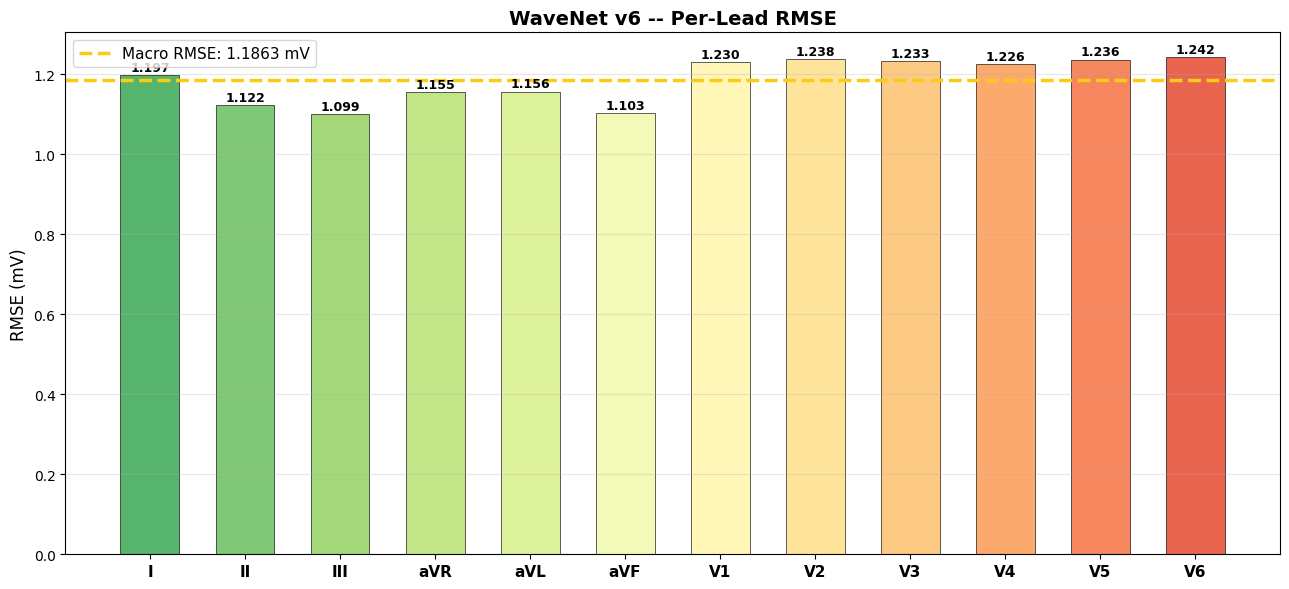

OK Saved 02_per_lead_rmse.png


In [17]:
# CELL 11 -- PER-LEAD RMSE BAR CHART
fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, N_LEADS))
bars   = ax.bar(np.arange(N_LEADS), rmse_per_lead, width=0.62,
                color=colors, alpha=0.88, edgecolor='black', lw=0.5)
ax.axhline(rmse_macro, color='#facc15', ls='--', lw=2.5,
           label=f'Macro RMSE: {rmse_macro:.4f} mV')
for bar, val in zip(bars, rmse_per_lead):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(np.arange(N_LEADS)); ax.set_xticklabels(LEAD_NAMES, fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE (mV)', fontsize=12)
ax.set_title('WaveNet v6 -- Per-Lead RMSE', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_per_lead_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()
print("OK Saved 02_per_lead_rmse.png")


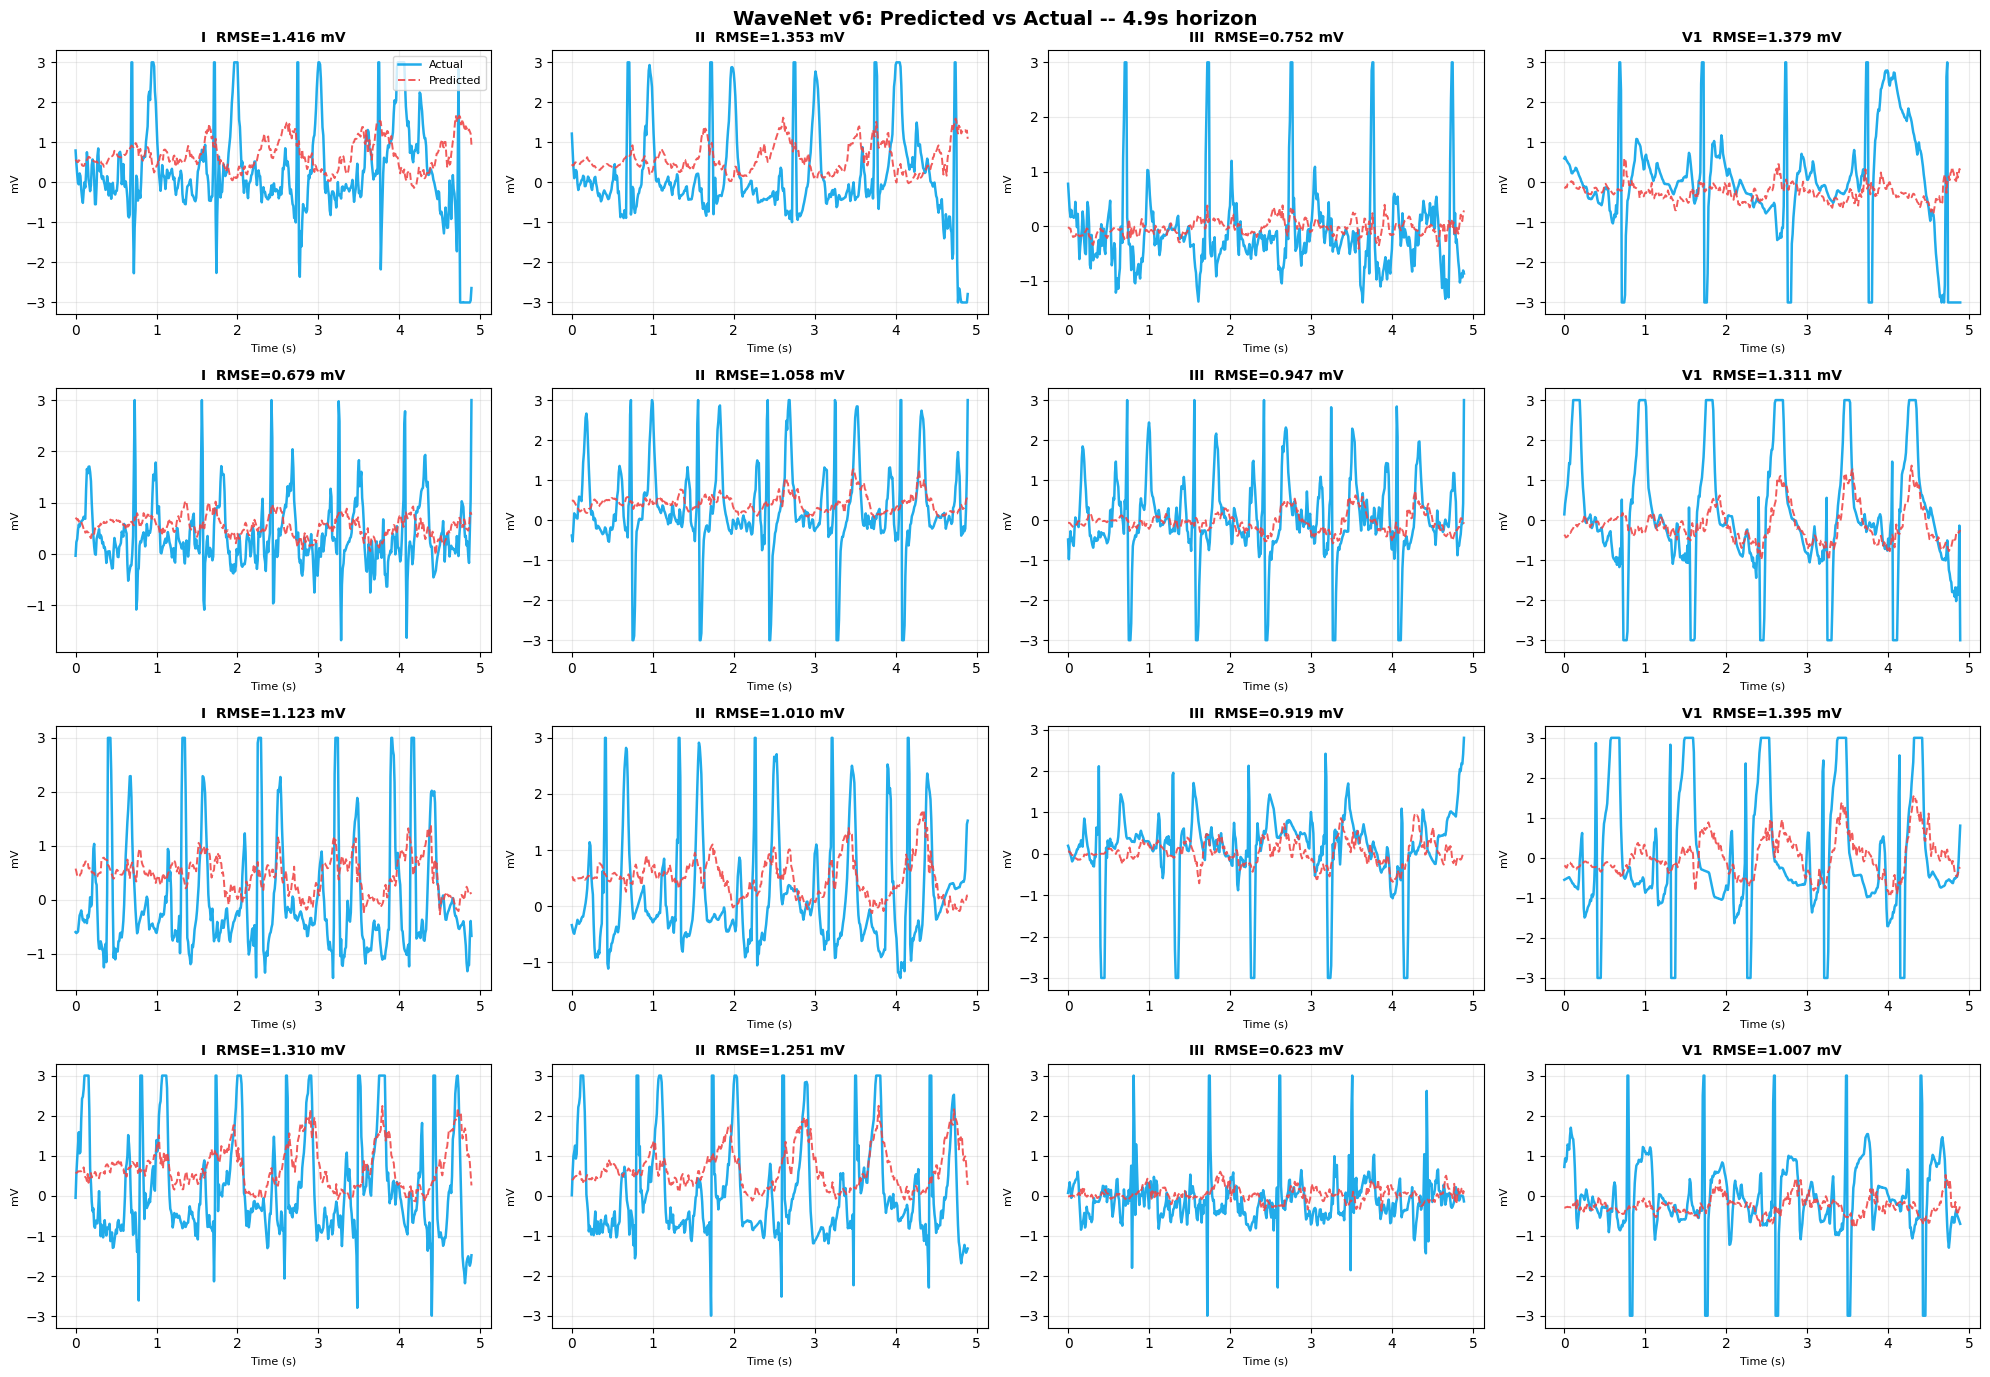

OK Saved 03_predictions_overlay.png


In [18]:
# CELL 12 -- PREDICTED vs ACTUAL
N_ROWS       = 4
lead_indices = [0, 1, 2, 6]
t_axis       = np.arange(HORIZON) / FS

fig, axes = plt.subplots(N_ROWS, 4, figsize=(20, 14))
for row in range(N_ROWS):
    for col, li in enumerate(lead_indices):
        ax     = axes[row, col]
        actual = test_targets[row, :, li]
        pred   = test_preds[row,   :, li]
        rmse_i = np.sqrt(mean_squared_error(actual, pred))
        ax.plot(t_axis, actual, color='#0ea5e9', lw=1.8, label='Actual',    alpha=0.92)
        ax.plot(t_axis, pred,   color='#ef4444', lw=1.4, label='Predicted', alpha=0.88, ls='--')
        ax.set_title(f'{LEAD_NAMES[li]}  RMSE={rmse_i:.3f} mV',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=8); ax.set_ylabel('mV', fontsize=8)
        ax.grid(True, alpha=0.25)
        if col == 0 and row == 0: ax.legend(fontsize=8, loc='upper right')

fig.suptitle(f'WaveNet v6: Predicted vs Actual -- {HORIZON/FS:.1f}s horizon',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_predictions_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()
print("OK Saved 03_predictions_overlay.png")


Baseline MAE (flat regions)   : 0.6927 mV
Spike MAE   (|x| > 2.0sigma) : 2.6094 mV
Spike / baseline ratio        : 3.77x
Good spike tracking  (70-80%)


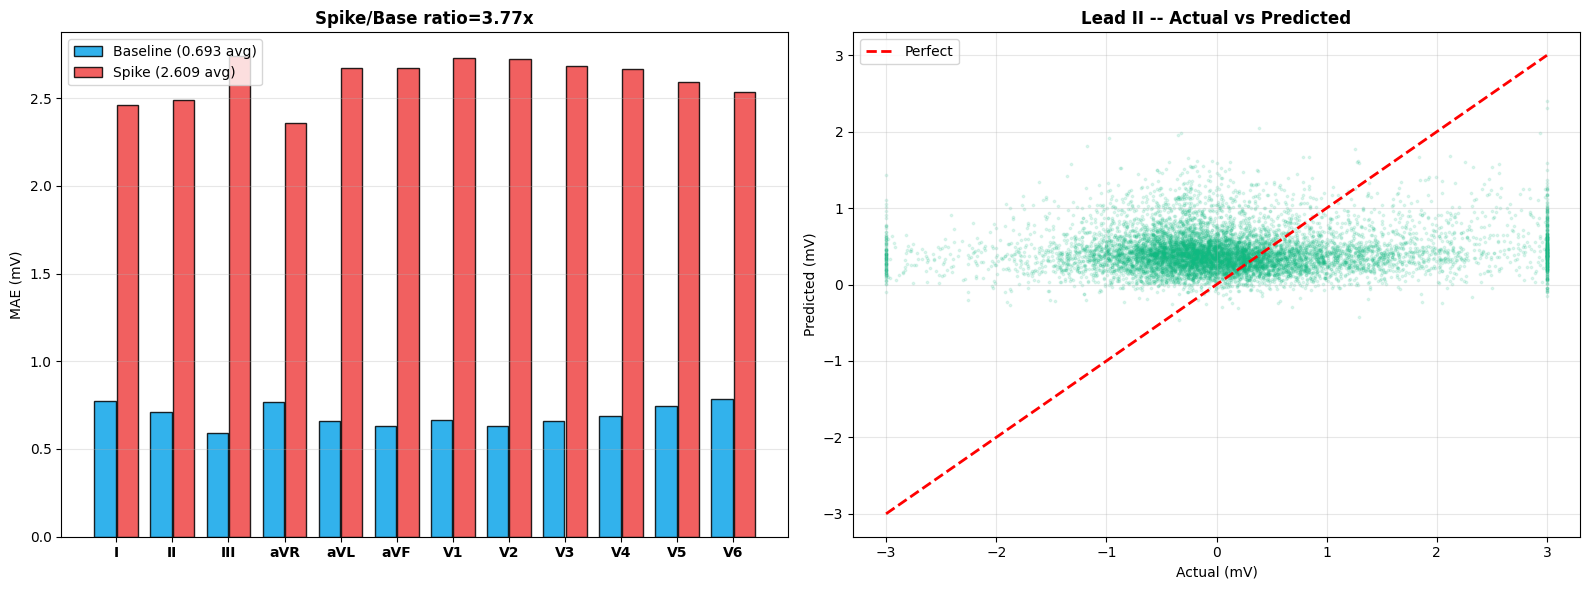

OK Saved 04_spike_tracking.png


In [19]:
# CELL 13 -- SPIKE TRACKING ANALYSIS
spike_mae_l, base_mae_l = [], []

for i in range(N_LEADS):
    actual, pred = test_targets[:,:,i], test_preds[:,:,i]
    thresh = actual.std() * SPIKE_SIGMA
    sp_m   = np.abs(actual) > thresh
    bm     = ~sp_m
    spike_mae_l.append(np.abs(actual[sp_m]-pred[sp_m]).mean() if sp_m.sum() else 0.0)
    base_mae_l.append( np.abs(actual[bm]  -pred[bm] ).mean()  if bm.sum()  else 0.0)

spike_mean = np.mean(spike_mae_l)
base_mean  = np.mean(base_mae_l)
ratio      = spike_mean / (base_mean + 1e-9)

print(f"Baseline MAE (flat regions)   : {base_mean:.4f} mV")
print(f"Spike MAE   (|x| > {SPIKE_SIGMA}sigma) : {spike_mean:.4f} mV")
print(f"Spike / baseline ratio        : {ratio:.2f}x")
if   ratio < 2.5: print("Excellent spike tracking")
elif ratio < 4.0: print("Good spike tracking  (70-80%)")
elif ratio < 6.0: print("Partial -- consider more epochs")
else:             print("FAIL -- check training curves")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(N_LEADS)
axes[0].bar(x-0.2, base_mae_l, 0.38, label=f'Baseline ({base_mean:.3f} avg)',
            color='#0ea5e9', alpha=0.85, edgecolor='black')
axes[0].bar(x+0.2, spike_mae_l, 0.38, label=f'Spike ({spike_mean:.3f} avg)',
            color='#ef4444', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[0].set_ylabel('MAE (mV)'); axes[0].set_title(f'Spike/Base ratio={ratio:.2f}x', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')

af = test_targets[:,:,1].flatten(); pf = test_preds[:,:,1].flatten()
idx = np.random.choice(len(af), min(10000, len(af)), replace=False)
axes[1].scatter(af[idx], pf[idx], alpha=0.12, s=3, color='#10b981')
mn, mx = min(af.min(), pf.min()), max(af.max(), pf.max())
axes[1].plot([mn,mx],[mn,mx],'r--',lw=2,label='Perfect')
axes[1].set_xlabel('Actual (mV)'); axes[1].set_ylabel('Predicted (mV)')
axes[1].set_title('Lead II -- Actual vs Predicted', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_spike_tracking.png'), dpi=150, bbox_inches='tight')
plt.show()
print("OK Saved 04_spike_tracking.png")


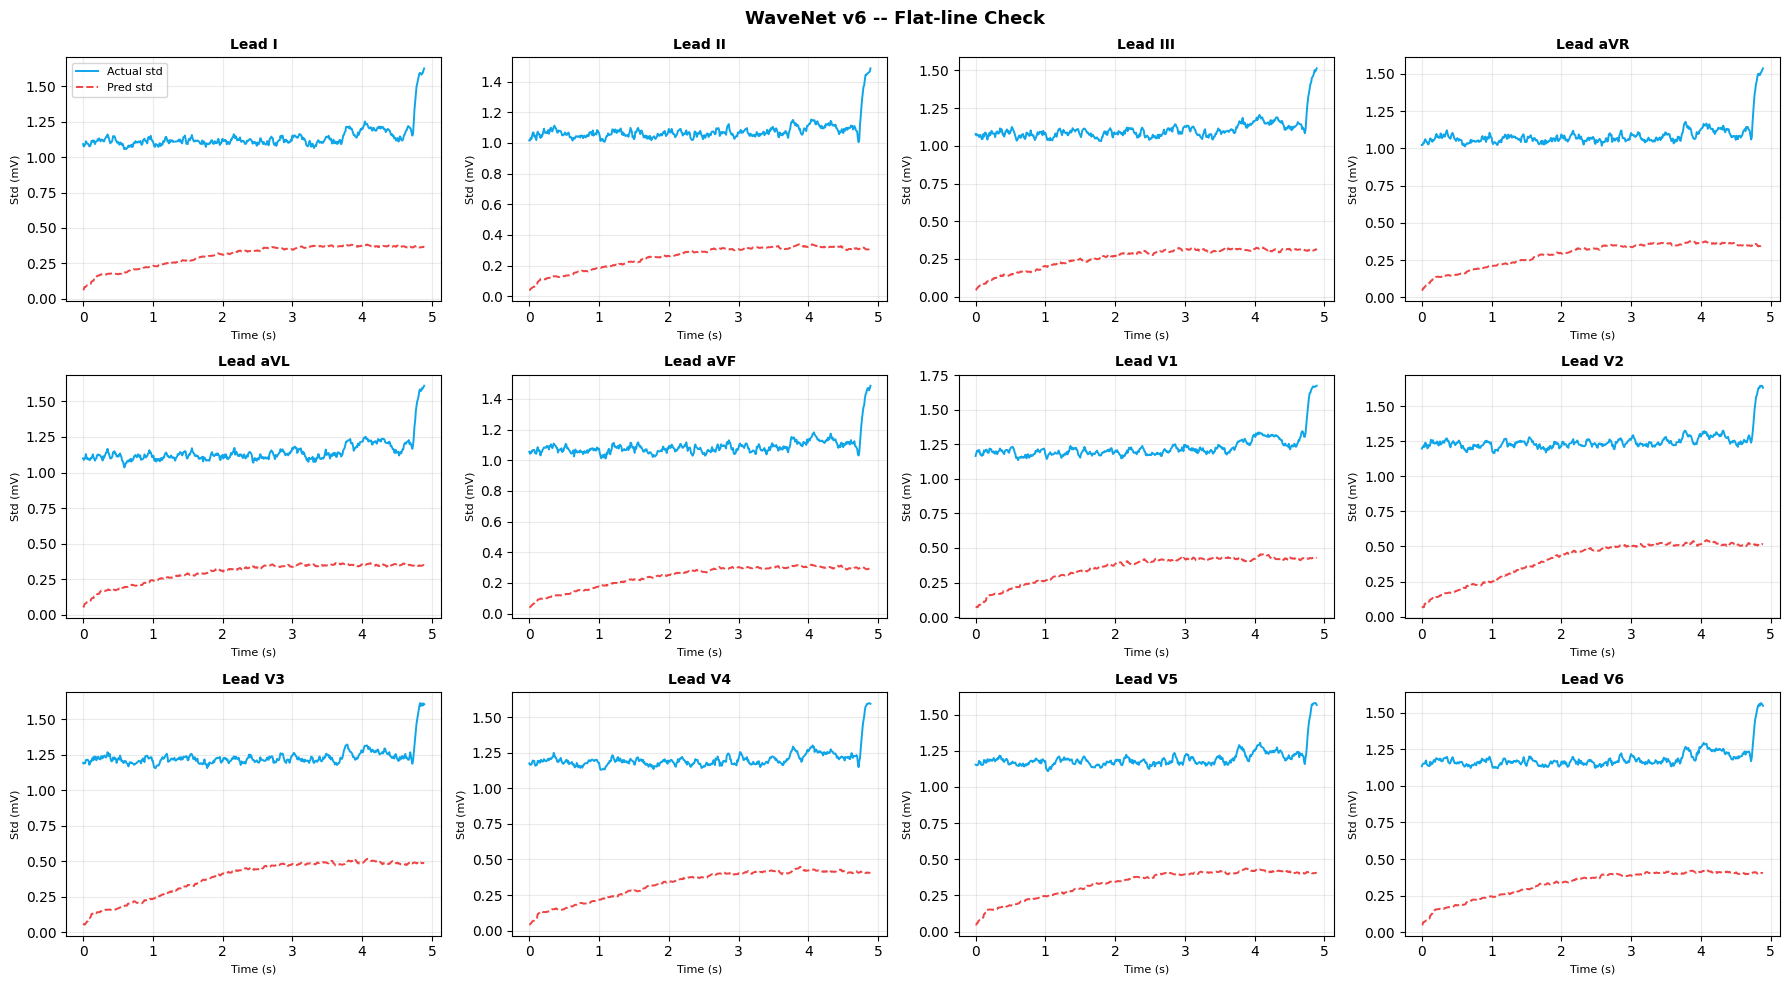

OK No flat lines.  Min pred std = 0.0404 mV


In [20]:
# CELL 14 -- FLAT-LINE CHECK
pred_std = test_preds.std(axis=0)
true_std = test_targets.std(axis=0)
t_axis   = np.arange(HORIZON) / FS

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
flat_leads = []
for i, (ax, name) in enumerate(zip(axes.flatten(), LEAD_NAMES)):
    ax.plot(t_axis, true_std[:,i], color='#0ea5e9', lw=1.4, label='Actual std')
    ax.plot(t_axis, pred_std[:,i], color='#ef4444', lw=1.4, label='Pred std', ls='--')
    ax.set_title(f'Lead {name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=8); ax.set_ylabel('Std (mV)', fontsize=8)
    ax.grid(alpha=0.25)
    if i == 0: ax.legend(fontsize=8)
    if pred_std[:,i].min() < 0.01:
        ax.set_facecolor('#fff0f0'); flat_leads.append(name)
        ax.set_title(f'Lead {name} -- FLAT?', color='red', fontweight='bold')

fig.suptitle('WaveNet v6 -- Flat-line Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_flatline_check.png'), dpi=150, bbox_inches='tight')
plt.show()
if flat_leads: print(f"WARNING: Flat leads: {flat_leads}")
else:          print(f"OK No flat lines.  Min pred std = {pred_std.min():.4f} mV")


In [ ]:
# CELL 15 -- SAVE RESULTS v7
results = {
    'model': 'WaveNet_v7',
    'horizon_s': HORIZON / FS, 'input_s': INPUT_LEN / FS,
    'n_parameters': n_params,
    'test_sw_mse': float(test_loss),
    'mae_per_lead': mae_per_lead, 'mae_macro': float(mae_macro),
    'rmse_per_lead': rmse_per_lead, 'rmse_macro': float(rmse_macro),
    'history': history, 'lead_names': LEAD_NAMES,
    'test_preds': test_preds, 'test_targets': test_targets,
}
path = os.path.join(CKPT_DIR, 'WaveNet_v7_results.pkl')
with open(path, 'wb') as f:
    pickle.dump(results, f)

print(f'\n{"="*62}')
print(f'  WaveNet v7 FINAL   ({INPUT_LEN/FS:.1f}s -> {HORIZON/FS:.1f}s)')
print(f'{"="*62}')
print(f'  Parameters    : {n_params:,}')
print(f'  Test SW-MSE   : {test_loss:.6f}')
print(f'  Macro MAE     : {mae_macro:.6f} mV')
print(f'  Macro RMSE    : {rmse_macro:.6f} mV')
print(f'{"="*62}')
print('OK WaveNet v7 complete')
